# Congestion Revenue Allocation Between Two Settlement Footprints

The market boundary **moves between settlements**: a day-ahead (EDAM) footprint
sits *inside* a larger real-time (WEIM) footprint, so a balancing authority can
be outside the market in the day-ahead clear and inside it in real time. The core
lesson is the **exogenous → endogenous** transition — a resource fixed
(self-scheduled) in the day-ahead becomes a priced decision in real time — and
what that does to the cross-settlement position ledger, a contingency, and its
accommodation.

It assumes the fundamentals notebook (nodal LMPs, congestion and transfer rent,
self-schedules) and runs on the shared libraries — `wscc9_model`, `footprints`,
`revenue_allocation`, `wscc9_figures`. The 5-6 interface is modelled as a
**parallel double circuit**, one per BA.

## 0. Setup

In [1]:
#@title ▶ Run me first — Colab setup (installs packages, fetches the helper modules)
# On Google Colab this installs the few non-default packages and downloads the
# three helper modules next to the notebook. Running locally it does nothing
# (the modules are already on disk), so the same notebook works in both places.
import sys, subprocess

def _sh(cmd):
    print("$", cmd)
    subprocess.run(cmd, shell=True, check=True)

if "google.colab" in sys.modules:
    _sh("pip install -q pypsa pandapower pycirclize")
    _base = "https://raw.githubusercontent.com/pdockery/wscc9-illustrative-model/main"
    for _f in ("ieee9_network.py", "seams_engine.py", "nodal_plot.py",
              "wscc9_model.py", "footprints.py", "revenue_allocation.py", "wscc9_figures.py"):
        _sh(f"wget -q {_base}/{_f} -O {_f}")
    print("Colab setup complete.")
else:
    print("Local run: using the modules already in this folder.")


Local run: using the modules already in this folder.


In [2]:
import sys, os, importlib
import warnings; warnings.filterwarnings('ignore')
import logging; logging.getLogger('pypsa').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('.'))

# Teaching libraries for the WSCC 9-bus illustrative repository.
import seams_engine, nodal_plot, wscc9_model, footprints, revenue_allocation, wscc9_figures
for _m in (seams_engine, nodal_plot, wscc9_model, footprints, revenue_allocation, wscc9_figures):
    importlib.reload(_m)
import wscc9_model as wm, footprints as fpmod, revenue_allocation as ra, wscc9_figures as figs
from wscc9_model import (
    build_network, make_engine, shift_factors, sf_table,
    BUS_COLORS, COORDS, RING_ORDER, ROTATION_DEG, CENTER_BUS,
)
from seams_engine import (
    compute_ptdf, MarketEngine, solve_engine_dispatch,
    physical_flows, seam_dual_gap, to_supply_demand, susceptance_widths,
    shed_segments, served_by_bus, served_demand,
)
from nodal_plot import (
    plot_network_topology, plot_nodal_circlize, plot_combined_letter,
    assign_bus_colors, BUS_PALETTE, TRANSIT_COLOR,
)
pd.set_option('display.width', 160)

def _df_to_latex(_df):
    if isinstance(_df, pd.Series):
        _df = _df.to_frame()
    _body = _df.to_latex(escape=True, na_rep='', float_format=lambda v: f'{(0.0 if v==0 else v):,.6g}')
    _ncol = _df.shape[1] + _df.index.nlevels
    if _ncol > 6:
        return '\\begin{center}\\resizebox{\\linewidth}{!}{%\n' + _body + '}\\end{center}'
    return '\\begin{center}{\\small\n' + _body + '}\\end{center}'

try:
    _ltx = get_ipython().display_formatter.formatters['text/latex']
    _ltx.for_type(pd.DataFrame, _df_to_latex)
    _ltx.for_type(pd.Series, _df_to_latex)
except Exception:
    pass

print('ready')

ready

In [3]:
# Teaching fleet/loads from wscc9_model (edit there, or override the dicts here).
GEN_FLEET = dict(wm.DEFAULT_GEN_FLEET)   # {gen: {bus, cost $/MWh, p_nom MW}}
LOADS     = dict(wm.DEFAULT_LOADS)       # {bus: MW}

# The 5-6 interface is a parallel DOUBLE CIRCUIT (one circuit per BA): build_network
# splits line_2 -> line_2_ba1 + line_2_ba2 (each 75 MW at 2x, electrically identical
# to the single 150 MW line). Bound here so EVERY clearing in this notebook uses it.
build_network = lambda line_ratings=None: wm.build_network(line_ratings, split_5_6=True)

print('loads (MW):', LOADS, '| 5-6 = parallel double circuit (line_2_ba1 + line_2_ba2)')
pd.DataFrame(GEN_FLEET).T[['bus', 'cost', 'p_nom']]

loads (MW):

{'5': 90.0, '7': 100.0, '9': 125.0}

| 5-6 = parallel double circuit (line_2_ba1 + line_2_ba2)

,bus,cost,p_nom
gen_slack_0,1,50.0,250.0
gen_0,2,35.0,300.0
gen_1,3,20.0,170.0


## 1. The model: one market clearing on a shared network

Every settlement in this notebook is the **same single-period, bid-based
security-constrained economic dispatch** on a shared 9-bus network: a market
engine optimises a set of resources against the network's limits **and** a
transfer limit, and reads prices off the dual variables. It is stated once here,
transfers included; later sections only change *which* resources and constraints
sit inside the clearing — and the composite figure is how every run is read, so
the pieces are not introduced separately.

**Nomenclature.** Sets are script capitals; an element is the matching lower-case
letter (upper-case for markets). Case carries meaning: lower-case $m$ is a
**line**, script $\mathcal M$ the **set** of lines.

| Symbol | Definition |
|---|---|
| $\mathcal N,\ n$ | buses |
| $\mathcal M,\ m$ | monitored lines (network constraints) |
| $\mathcal R,\ i$ | resources (generators) the clearing optimises; $g_i,\ \bar g_i,\ c_i$ dispatch, cap, cost |
| $d_n,\ \mathrm{exo}_n$ | load, and fixed price-taking exogenous injection, at bus $n$ |
| $SF_{n,m},\ \bar F_m$ | shift factor of bus $n$ on line $m$; line limit |
| $\lambda,\ \lambda_n,\ \mu_m$ | energy price; nodal LMP; line $m$'s congestion dual |
| $\mathcal N_a$, $a$ | a balancing authority's bus set; $\mathcal N_1$ is BA-1's |
| $E,\ \bar E,\ \mu_T$ | net interchange out of BA-1; its scheduling limit; the transfer dual |
| $R,\ R_T$ | congestion rent $\sum_m\lvert\mu_m F_m\rvert$; transfer rent $\lvert\mu_T E\rvert$ |

**Dispatch and the energy price.**

$$\min_{0\le g_i\le\bar g_i}\sum_{i\in\mathcal R} c_i g_i
  \quad\text{s.t.}\quad
  \sum_{i\in\mathcal R} g_i=\sum_{n\in\mathcal N} d_n-\sum_{n\in\mathcal N}\mathrm{exo}_n\ \ [\lambda]. \qquad (1)$$

$\mathrm{exo}_n>0$ injects into the footprint (an import), $<0$ withdraws. A
power-balance **relaxation** (load shed at penalty $V$, `SHED_PRICE`) keeps the
clearing feasible behind a binding line; it is slack in every example here.

**Flow, limits, and the nodal price.**

$$F_m=\sum_{n\in\mathcal N} SF_{n,m}\,p^{\mathrm{inj}}_n,\quad
  -\bar F_m\le F_m\le\bar F_m\ \ [\mu_m],\qquad
  \lambda_n=\lambda+\sum_{m\in\mathcal M} SF_{n,m}\,\mu_m. \qquad (2)$$

The LMP is the energy price plus shift-factor-weighted congestion duals — formed
from the network, never read as a gap between two nodes. The **congestion rent**
is the wedge it opens between load payments and generation revenue,

$$R=\sum_{m\in\mathcal M}\lvert\mu_m F_m\rvert. \qquad (3)$$

**The transfer (transport) layer.** Between BA-1 (bus set $\mathcal N_1$) and
BA-2, the **net interchange** out of BA-1 and its scheduling limit are

$$E=\sum_{i:\,\mathrm{bus}(i)\in\mathcal N_1} g_i-\sum_{n\in\mathcal N_1} d_n
   =\!\!\sum_{m\in\partial\mathcal N_1}\!\! s_m F_m,\qquad
  -\bar E\le E\le\bar E\ \ [\mu_T], \qquad (4)$$

with $s_m=\pm1$ the boundary orientation. Lossless DC makes the scheduled
interchange and the summed physical boundary flow the same number. Every BA-1
bus then carries the **same** extra term, and the transfer earns its own rent:

$$\lambda_n=\lambda+\sum_{m\in\mathcal M} SF_{n,m}\,\mu_m+\mathbb 1\{n\in\mathcal N_1\}\,\mu_T,
  \qquad R_T=\lvert\mu_T\,E\rvert. \qquad (5)$$

With nothing else binding, prices are flat within each BA and differ between them
by $\lvert\mu_T\rvert$ — the transfer splits the single energy price into two
BA-level prices. $R_T$ is a **second revenue stream** beside the congestion rent
$R$.

**Reading the composite.** Each clearing is one figure: the **network panel** (DC
flows, congested lines red, a *Transfers* inset for the interchange) beside the
**nodal-dispatch panel** (merit-order bars with each bus's LMP drawn over its
marginal cost — the gap is inframarginal rent). The worked base case is below.


In [4]:
pt = compute_ptdf(build_network(), slack_bus='1')   # split network -> has line_2_ba1 / line_2_ba2

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


In [5]:
## -- EDIT -- the two BAs, and the lines each manages. The 5-6 interface is a
## parallel double circuit -- one circuit per BA (the ownership the contingency turns on).
BA_DEFS = {'BA-1': ['2', '8', '7', '6', '3'], 'BA-2': ['1', '9', '4', '5']}
BA_LINES = {
    'BA-1': ['line_2_ba1', 'line_3', 'line_4', 'line_5', 'line_6'],   # line_2_ba1 = BA-1's 5-6 circuit
    'BA-2': ['line_0', 'line_1', 'line_2_ba2', 'line_7', 'line_8'],   # line_2_ba2 = BA-2's 5-6 circuit; line_7 = tie 8-9
}
BA_COLORS = {'BA-1': '#993AFF', 'BA-2': '#2471A3'}
# ---------------------------------------------------------------------------
pt = compute_ptdf(build_network(), slack_bus='1')
fp = fpmod.make(pt, BA_DEFS, BA_COLORS, manage=BA_LINES, tie_label='tie')
ba_of = fp.fp_of
LINE_BA = fp.line_assign
AREAS = fp.areas
ties = fp.ties
LOADS_ALL = dict(LOADS)
line_kind = lambda _pt, l: fp.line_kind(_pt, l)
ba_line_colors = lambda _pt: fp.line_colors(_pt)
BA_GROUPS = fp.groups(pt)
print('BA-1 manages:', [l for l in pt.lines if LINE_BA[l] == 'BA-1'])
print('BA-2 manages:', [l for l in pt.lines if LINE_BA[l] == 'BA-2'])
print('tie lines:', ties)

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


BA-1 manages:

['line_3', 'line_4', 'line_5', 'line_6', 'line_2_ba1']

BA-2 manages:

['line_0', 'line_1', 'line_7', 'line_8', 'line_2_ba2']

tie lines:

['line_7', 'line_2_ba1', 'line_2_ba2']

In [6]:
# Methodology — implemented in revenue_allocation.py (edit there to refine the
# allocation rule); bound here to this notebook's footprint `fp`.
ba_settlement            = lambda res, loads: ra.ba_settlement(fp, res, loads)
line_rent_table          = lambda res, pt: ra.line_rent_table(fp, res, pt)
border_separation        = lambda res, pt: ra.border_separation(fp, res, pt)
allocate_congestion_rent = lambda res, pt, loads, **kw: ra.allocate_congestion_rent(fp, res, pt, loads, **kw)
compare_methods          = lambda res, pt, loads: ra.compare_methods(fp, res, pt, loads)
print('methodology bound: ba_settlement, line_rent_table, border_separation, '
      'allocate_congestion_rent, compare_methods  (see revenue_allocation.py)')

methodology bound: ba_settlement, line_rent_table, border_separation, allocate_congestion_rent, compare_methods  (see revenue_allocation.py)

In [7]:
# Presentation helpers — figures from wscc9_figures.py, ledgers from
# revenue_allocation.py; bound to fp.
from revenue_allocation import settlement_by_bus, capacity_value_by_line
revenue_table = lambda res, pt, loads: ra.revenue_table(fp, res, pt, loads)

def example_figure(net, pt, engine, res, **kw):
    return figs.footprint_figure(net, pt, fp, engine, res, **kw)

print('presentation bound: example_figure, revenue_table, settlement_by_bus, capacity_value_by_line')

presentation bound: example_figure, revenue_table, settlement_by_bus, capacity_value_by_line

In [8]:
# Aggregation + autarky helpers (per AREA) from revenue_allocation.py; bound to fp.
COST = ra.cost_by_bus(GEN_FLEET)                          # bus -> marginal cost
_agg = lambda result, area: ra._agg(fp, result, area, LOADS_ALL, COST)
independent_clear = lambda rat, shed_price=None: ra.independent_clear(fp, rat, shed_price=shed_price, split_5_6=True)
print('aggregation helpers bound: COST, _agg, independent_clear (5-6 split)')

aggregation helpers bound: COST, _agg, independent_clear (5-6 split)

In [9]:
# -- EDIT -- knobs shared by every clearing in this notebook
SHED_PRICE   = 150.0               # load-shed relaxation penalty ($/MWh); slack in every example
LINE_RATINGS = {'line_4': 40.0}    # the worked internal-constraint example (line 6-7, internal to BA-1)
print('knobs:  SHED_PRICE', SHED_PRICE, ' MWh |  worked example LINE_RATINGS', LINE_RATINGS)


knobs:  SHED_PRICE

150.0

 MWh |  worked example LINE_RATINGS

{'line_4': 40.0}

In [10]:
# -- EDIT -- the transfer (interchange scheduling) limit ---------------------
TIE_CAP = float(sum(pt.s_nom[pt.line_idx[l]] for l in ties))   # combined tie rating: the physical envelope
TRANSFER_LIMIT = TIE_CAP    # Ebar; lower it below TIE_CAP to make the SCHEDULE bind
# -- EDIT -- allocation methodologies for the two revenue streams -------------
CONGESTION_METHODS = [1, 2]                   # congestion rules to tabulate (one ledger each)
TRANSFER_METHODS   = [1, 2]                   # transfer rules: 1 = fixed shares, 2 = net-payer
TRANSFER_SPLIT = {'BA-1': 0.5, 'BA-2': 0.5}   # Method T1's shares sigma_a (EDAM: equal split)
# ----------------------------------------------------------------------------
assert set(TRANSFER_SPLIT) == set(BA_DEFS) and abs(sum(TRANSFER_SPLIT.values()) - 1.0) < 1e-9, \
    'TRANSFER_SPLIT must cover both BAs and sum to 1'
T_NAMES = ra.T_NAMES

# Transfer model — implemented in revenue_allocation.py / wscc9_figures.py; bound to fp.
transfer_rent          = ra.transfer_rent
allocate_transfer_rent = lambda res, loads, t_method: ra.allocate_transfer_rent(fp, res, loads, t_method, TRANSFER_SPLIT)
solve_with_transfer    = lambda ratings, ebar: ra.solve_with_transfer(fp, ratings, ebar, shed_price=SHED_PRICE, split_5_6=True)
transfer_ledger        = lambda res, p, loads, method, t_method, indep: \
    ra.transfer_ledger(fp, res, p, loads, method, t_method, indep, TRANSFER_SPLIT)

def draw_net_dispatch(ax, res, ebar, engine):
    return figs.draw_net_dispatch(ax, fp, res, ebar, engine, TIE_CAP)

def transfer_figure(n, p, e, r, ebar, suptitle=None):
    return figs.transfer_figure(n, p, fp, e, r, ebar, TIE_CAP, suptitle=suptitle)

print(f'transfer model bound: TIE_CAP = {TIE_CAP:.0f} MW (combined tie rating);  '
      f'TRANSFER_LIMIT = {TRANSFER_LIMIT:.0f} MW')
print('allocation knobs: CONGESTION_METHODS = ' + str(CONGESTION_METHODS)
      + ',  TRANSFER_METHODS = ' + str(TRANSFER_METHODS) + ' (T1 shares: '
      + ' / '.join(f'{ba} {TRANSFER_SPLIT[ba]:.0%}' for ba in BA_DEFS) + ')')

transfer model bound: TIE_CAP = 400 MW (combined tie rating);  TRANSFER_LIMIT = 400 MW

allocation knobs: CONGESTION_METHODS = [1, 2],  TRANSFER_METHODS = [1, 2] (T1 shares: BA-1 50% / BA-2 50%)

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


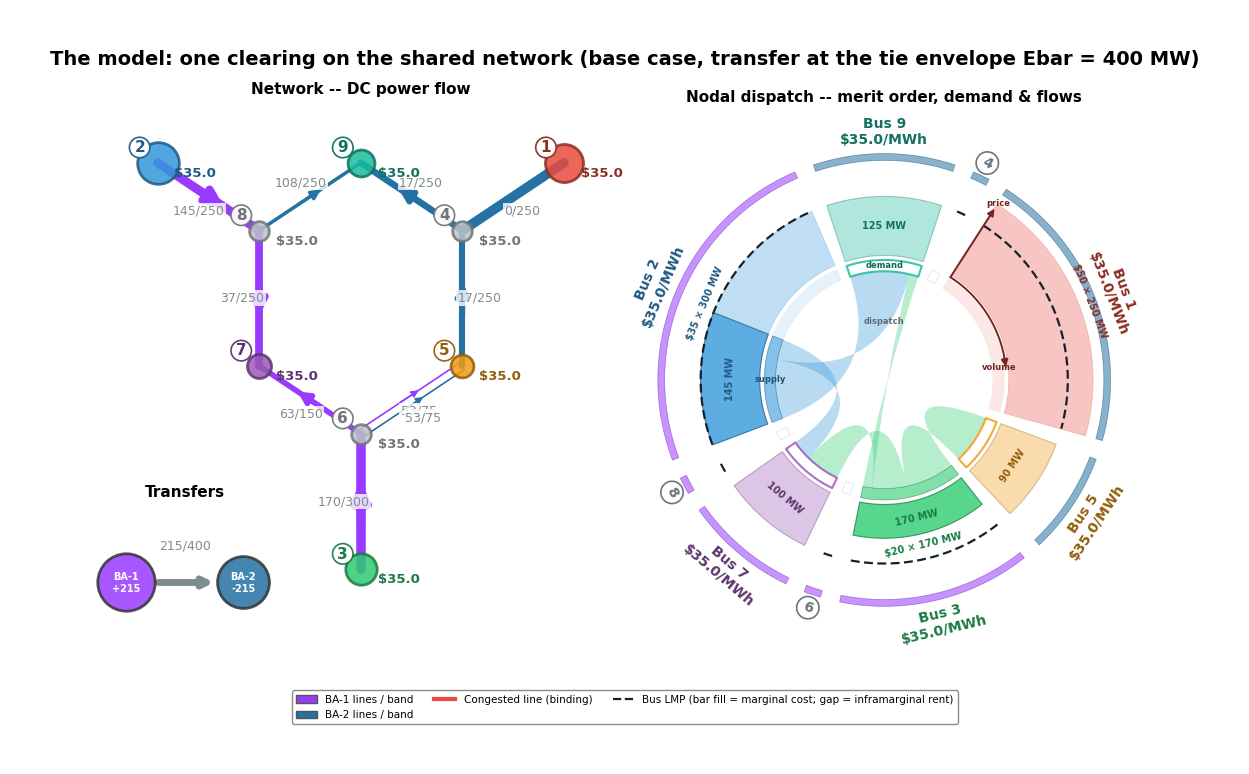

LMP by bus:

{'1': np.float64(35.0), '2': np.float64(35.0), '3': np.float64(35.0), '4': np.float64(35.0), '5': np.float64(35.0), '6': np.float64(35.0), '7': np.float64(35.0), '8': np.float64(35.0), '9': np.float64(35.0)}

interchange E = 215 MW of Ebar = 400 (mu_T = 0.00); binding lines:

none

In [11]:
# The base clearing as one composite: network + the Transfers inset + nodal
# dispatch. This is the single figure every later run is read from.
nB, pB, eB, rB = solve_with_transfer({}, TRANSFER_LIMIT)
fig = transfer_figure(nB, pB, eB, rB, TRANSFER_LIMIT,
                      suptitle='The model: one clearing on the shared network (base case, '
                               f'transfer at the tie envelope Ebar = {TRANSFER_LIMIT:.0f} MW)')
plt.show()
print('LMP by bus:', {b: round(rB.lmp[b], 1) for b in pB.buses})
print(f'interchange E = {rB.interchange_mw:.0f} MW of Ebar = {TRANSFER_LIMIT:.0f} (mu_T = {rB.interchange_dual:.2f}); '
      f'binding lines:', {l: round(rB.line_dual[l], 1) for l in pB.lines if abs(rB.line_dual[l]) > 1e-3} or 'none')


## 2. Two footprints, two settlements

The day-ahead market does not cover the whole interconnection. **BA-1** is a
day-ahead (**EDAM**) participant; **BA-2** is not — it joins only in
**real-time** (**WEIM**). So the market footprint **moves between settlements**.

**Day-ahead is a commitment problem; real-time is a dispatch problem.** In
practice the day-ahead market is a **unit-commitment** optimisation — it decides
which resources to *commit*, including committing units specifically to relieve a
constraint — while real-time is **economic dispatch** over the already-committed
fleet. We abstract the commitment dimension away here (single-period,
energy-only), but it is exactly the **exogenous/endogenous** line this notebook
draws:

- the BA **outside** the day-ahead market commits its resources **privately** —
  a self-schedule the market takes as a fixed $\mathrm{exo}$ injection;
- the BA **inside** it has its resources **committed and dispatched by the market
  optimisation**, within the network constraints.

When the footprint expands in real-time, the privately-committed resources become
market-dispatched: **what was exogenous becomes endogenous.** Two nestings encode
that, and they are the heart of the notebook:

- **Constraints** $\mathcal M^{DA}_{\mathrm{act}}\subseteq\mathcal M^{RT}_{\mathrm{act}}$
  — day-ahead monitors only the lines inside the EDAM footprint (BA-1's own lines
  and the border ties); real-time monitors every line, including BA-2's.
- **Transfers** — none are optimised day-ahead (the interchange is a fixed
  bilateral $E_0$); in real-time the BA-1↔BA-2 interchange is optimised.

The same network, fleet, and shift factors from Section 1 carry over; only **who
is inside the market** changes. The cell below fixes the footprints, the nested
constraint sets, and the day-ahead bilateral $E_0$.


In [12]:
# ---- The two settlements: the moving market boundary ----------------------
DA_MARKET = ['BA-1']             # EDAM (day-ahead) participants
RT_MARKET = ['BA-1', 'BA-2']     # WEIM (real-time) adds BA-2
RT_BUSES  = [b for ba in RT_MARKET for b in BA_DEFS[ba]]

# Nested activated-constraint sets:  M_act^DA  subset of  M_act^RT.
# Day-ahead monitors BA-1's own lines + the border ties; NOT BA-2-internal lines
# (their relieving resources are outside the day-ahead footprint). Real-time
# monitors every line.
MACT_RT = list(pt.lines)
MACT_DA = [l for l in pt.lines
           if not (line_kind(pt, l)[0] == 'internal'
                   and line_kind(pt, l)[1] not in DA_MARKET)]
assert set(MACT_DA) <= set(MACT_RT), 'day-ahead constraints must nest inside real-time'

# Day-ahead self-scheduled bilateral BA-1 -> BA-2 (fixed, NOT optimised). The
# real-time run replaces this with an optimised interchange limit.
E0_DA = 60.0    # MW BA-2 buys from BA-1 day-ahead as a fixed self-schedule

print('Settlements (the moving market boundary):')
print('  day-ahead (EDAM) footprint:', DA_MARKET, '=', BA_DEFS['BA-1'])
print('  real-time (WEIM) footprint:', RT_MARKET)
print('  M_act^DA (monitored day-ahead):', MACT_DA)
print('  M_act^RT (monitored real-time):', MACT_RT)
print('  nested:', set(MACT_DA) <= set(MACT_RT),
      '| BA-2-internal lines added in RT:', sorted(set(MACT_RT) - set(MACT_DA)))
print(f'  day-ahead fixed bilateral E0 = {E0_DA:.0f} MW (BA-1 -> BA-2)')


Settlements (the moving market boundary):

  day-ahead (EDAM) footprint:

['BA-1']

=

['2', '8', '7', '6', '3']

...

  nested:

True

| BA-2-internal lines added in RT:

['line_0', 'line_1', 'line_8']

  day-ahead fixed bilateral E0 = 60 MW (BA-1 -> BA-2)

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:matplotlib.font_manager:Fontsize 0.10 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt


INFO:matplotlib.font_manager:Fontsize 0.10 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt


INFO:matplotlib.font_manager:Fontsize 0.10 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt


INFO:matplotlib.font_manager:Fontsize 0.10 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt


...

INFO:matplotlib.font_manager:Fontsize 0.10 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt


INFO:matplotlib.font_manager:Fontsize 0.10 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt


INFO:matplotlib.font_manager:Fontsize 0.10 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt


INFO:matplotlib.font_manager:Fontsize 0.10 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt


INFO:matplotlib.font_manager:Fontsize 0.10 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt


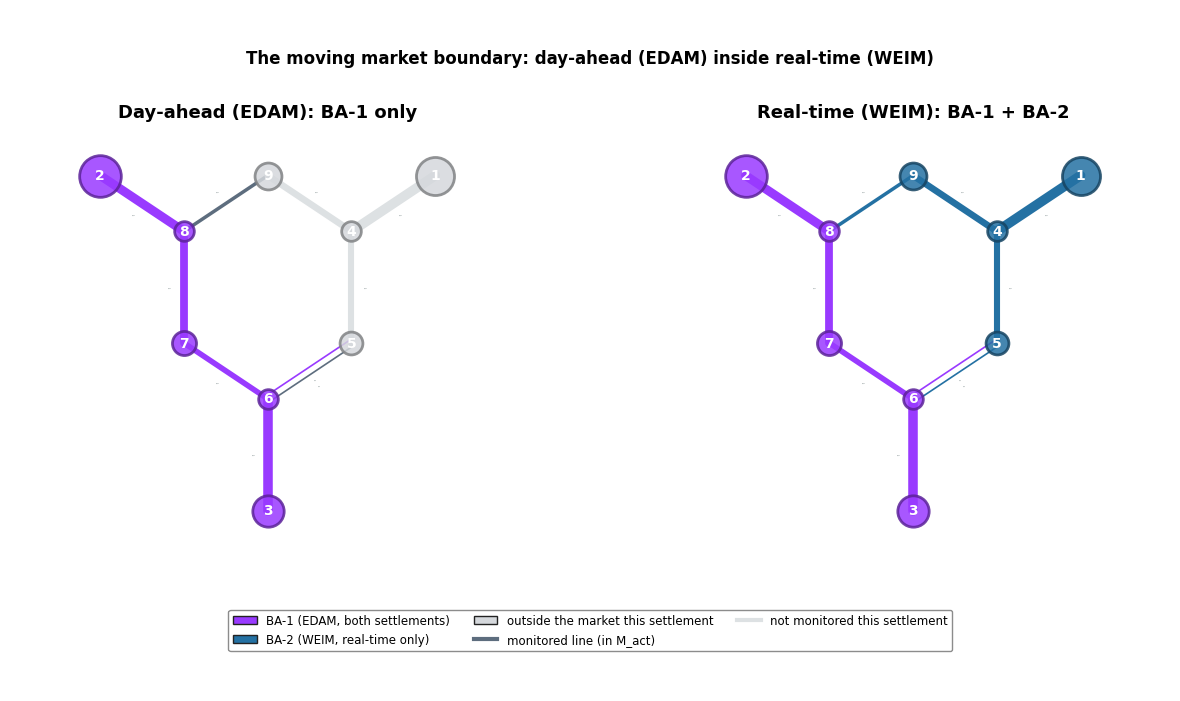

Day-ahead monitors

7

lines; real-time adds the BA-2-internal lines

['line_0', 'line_1', 'line_8']

->

10

lines.

In [13]:
# Footprint map, drawn with the SAME network renderer as the composite figures.
# Buses are coloured by BA (greyed where outside the market that settlement);
# monitored lines take the colour of their BA ONLY when that BA participates this
# settlement (so a BA-2 tie monitored day-ahead stays grey, not blue); lines not
# monitored stay faint grey. (No flows: a membership/monitoring map, not a dispatch.)
supF = {}
for g, s in GEN_FLEET.items():
    supF.setdefault(str(s['bus']), []).append(
        {'unit_id': g, 'price': s['cost'], 'volume': s['p_nom'],
         'capacity': s['p_nom'], 'accepted_volume': 0.0})
demF = {b: float(v) for b, v in LOADS.items()}

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.6))
for ax, (title, market, mact) in zip(axes, [
        ('Day-ahead (EDAM): BA-1 only', DA_MARKET, MACT_DA),
        ('Real-time (WEIM): BA-1 + BA-2', RT_MARKET, MACT_RT)]):
    inmkt = {b for ba in market for b in BA_DEFS[ba]}
    bcol = {b: (BA_COLORS.get(ba_of(b), '#AAB7B8') if b in inmkt else '#D5D8DC') for b in pt.buses}
    lcol = {l: (BA_COLORS[LINE_BA[l]] if (l in mact and LINE_BA.get(l) in market) else
                ('#5D6D7E' if l in mact else '#DDE1E3')) for l in pt.lines}
    plot_network_topology(build_network(), supply_by_bus=supF, demand_by_bus=demF,
                          bus_colors=bcol, bus_coords=COORDS, line_colors=lcol,
                          line_widths=susceptance_widths(pt), line_flows={},
                          lmp_only=True, title=title, ax=ax, flow_label_fontsize=0.1)
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
handles = [mpatches.Patch(fc=BA_COLORS['BA-1'], ec='#222', label='BA-1 (EDAM, both settlements)'),
           mpatches.Patch(fc=BA_COLORS['BA-2'], ec='#222', label='BA-2 (WEIM, real-time only)'),
           mpatches.Patch(fc='#D5D8DC', ec='#222', label='outside the market this settlement'),
           Line2D([0], [0], color='#5D6D7E', lw=3, label='monitored line (in M_act)'),
           Line2D([0], [0], color='#DDE1E3', lw=3, label='not monitored this settlement')]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.01),
           ncol=3, fontsize=8.5, framealpha=0.9, edgecolor='gray')
plt.suptitle('The moving market boundary: day-ahead (EDAM) inside real-time (WEIM)',
             fontweight='bold')
plt.tight_layout(rect=[0, 0.04, 1, 0.97])
plt.show()
print('Day-ahead monitors', len(MACT_DA), 'lines; real-time adds the BA-2-internal lines',
      sorted(set(MACT_RT) - set(MACT_DA)), '->', len(MACT_RT), 'lines.')


### The two clearings — exogenous in the day-ahead, endogenous in real-time

Both settlements solve the **same clearing** of Section 1; what differs is the
**resource set the engine optimises** and the **constraints it activates**.

**Day-ahead (EDAM).** The engine optimises BA-1's resources only. BA-2 is
exogenous — it self-commits its own units to serve its own load $d^{B2}_n$ net of
the fixed bilateral $E_0$, and enters BA-1's clear as a **fixed injection**

$$\mathrm{exo}^{DA}_n=g^{B2}_n-d^{B2}_n\ \ (n\in\mathcal N_{B2}),\qquad
  \sum_{n\in\mathcal N_{B2}}\mathrm{exo}^{DA}_n=-E_0. \qquad (6)$$

BA-1 minimises its own cost subject to balance and the **day-ahead** constraint
set $\mathcal M^{DA}_{\mathrm{act}}$ (eqs. (1)–(2) over $\mathcal R^{B1}$). The
bilateral $E_0$ is **data, not a decision** — the day-ahead market does not move
it to the economic level, because the counterparty is outside the optimisation.

**Real-time (WEIM).** The footprint expands to BA-1 + BA-2. Every former
$\mathrm{exo}$ injection is now a **decision variable** $g^{B2}_i$, the monitored
set grows to $\mathcal M^{RT}_{\mathrm{act}}\supseteq\mathcal M^{DA}_{\mathrm{act}}$,
and the interchange becomes an **optimised transfer** with limit $\bar E$ and dual
$\mu_T$ (eqs. (4)–(5)):

$$\text{day-ahead: } g^{B2}\ \text{fixed},\ E=E_0\ \text{fixed}
  \qquad\longrightarrow\qquad
  \text{real-time: } g^{B2}\ \text{priced},\ -\bar E\le E\le\bar E\ [\mu_T]. \qquad (7)$$

*The transition in one line.* **What is exogenous in the day-ahead becomes
endogenous in real-time:** BA-2's commitment goes from a private self-schedule to
a priced market decision, and the interchange from a fixed $E_0$ to an optimised
$E$. That single change is what the runs below — and the later contingency —
trace through prices, rents, and positions.


In [14]:
# ---- The two settlement clearings -----------------------------------------
def da_exo(E0):
    """BA-2 (outside the day-ahead market) self-commits: its own units serve its
    own load minus the fixed bilateral import E0 from BA-1. Returns the exogenous
    injection {bus: MW} BA-2 presents to BA-1's day-ahead clear -- net -E0 (eq. 6)."""
    exo = {b: -float(LOADS[b]) for b in BA_DEFS['BA-2'] if b in LOADS}
    need = sum(float(LOADS[b]) for b in BA_DEFS['BA-2'] if b in LOADS) - E0
    for g, s in sorted(((g, s) for g, s in GEN_FLEET.items()
                        if ba_of(s['bus']) == 'BA-2'), key=lambda kv: kv[1]['cost']):
        take = max(0.0, min(need, s['p_nom'])); need -= take
        exo[s['bus']] = exo.get(s['bus'], 0.0) + take
    return exo

def da_clear(ratings=None, E0=E0_DA):
    """Day-ahead (EDAM): optimise BA-1 only; BA-2 fixed as exo; transfer NOT
    optimised; monitoring the day-ahead set M_act^DA."""
    n = build_network(ratings or {}); p = compute_ptdf(n, slack_bus='1')
    eng = make_engine('BA-1 (EDAM, day-ahead)', BA_DEFS['BA-1'], activated=MACT_DA)
    r = solve_engine_dispatch(p, eng, exo=da_exo(E0), shed_price=SHED_PRICE)
    return n, p, eng, r

def rt_clear(ratings=None, ebar=None):
    """Real-time (WEIM): co-optimise BA-1 + BA-2; monitoring M_act^RT; optional
    optimised interchange limit ebar on the BA-1<->BA-2 transfer."""
    n = build_network(ratings or {}); p = compute_ptdf(n, slack_bus='1')
    eng = make_engine('WEIM (real-time)', RT_BUSES, activated=MACT_RT)
    ix = (BA_DEFS['BA-1'], float(ebar)) if ebar is not None else None
    r = solve_engine_dispatch(p, eng, interchange=ix, shed_price=SHED_PRICE)
    return n, p, eng, r

def system_production_cost(res, E0=None):
    """System production cost. In real-time every unit is in res.gen_by_bus; in
    the day-ahead clear BA-2's self-schedule is exogenous, so add its cost from E0."""
    pc = sum(COST.get(b, 0.0) * res.gen_by_bus.get(b, 0.0) for b in pt.buses)
    if E0 is not None:
        ex = da_exo(E0)
        pc += sum(COST.get(b, 0.0) * max(0.0, ex.get(b, 0.0)) for b in BA_DEFS['BA-2'])
    return pc

print('clearings loaded: da_clear (BA-1 only, BA-2 exo), rt_clear (BA-1+BA-2, transfer optimised)')


clearings loaded: da_clear (BA-1 only, BA-2 exo), rt_clear (BA-1+BA-2, transfer optimised)

## 3. The two settlement runs

One example, two settlements. The internal BA-1 limit `line_4` (6→7) is set to
40 MW — the established constraint-activation scenario. The **day-ahead** run
optimises BA-1 with BA-2 fixed (bilateral $E_0$); the **real-time** run
co-optimises both and optimises the interchange. Read the two clearings side by
side: where the megawatts come from, what the network costs, and what each
footprint settles.


In [15]:
# -- EDIT -- the scenario (an internal BA-1 limit) and the real-time transfer knob
SCN     = {'line_4': 40.0}    # 6-7, internal to BA-1
EBAR_RT = TIE_CAP             # real-time interchange optimised at the tie envelope (efficient)
# ---------------------------------------------------------------------------
nDA, pDA, eDA, rDA = da_clear(SCN, E0=E0_DA)
nRT, pRT, eRT, rRT = rt_clear(SCN, ebar=EBAR_RT)

# Day-ahead generation includes BA-2's exogenous self-schedule (out of market).
exoDA = da_exo(E0_DA)
da_gen = dict(rDA.gen_by_bus)
for b in BA_DEFS['BA-2']:
    if exoDA.get(b, 0.0) > 0:
        da_gen[b] = da_gen.get(b, 0.0) + exoDA[b]

# The price each footprint FACES day-ahead. BA-1 settles at the day-ahead market
# LMP. BA-2 is OUTSIDE the market, so the price it faces is its own self-supply
# marginal cost (its dearest running unit) -- NOT the engine's network-implied
# shadow price at its buses, which would wrongly imply access to BA-1's cheap
# energy it cannot actually buy day-ahead.
_ba2_run = [s['cost'] for g, s in GEN_FLEET.items()
            if ba_of(s['bus']) == 'BA-2' and exoDA.get(s['bus'], 0.0) > 0]
BA2_SELF = max(_ba2_run) if _ba2_run else float('nan')
da_price = {b: (rDA.lmp[b] if ba_of(b) in DA_MARKET else BA2_SELF) for b in pt.buses}

pcDA, pcRT = system_production_cost(rDA, E0=E0_DA), system_production_cost(rRT)
cmp = pd.DataFrame({b: {
    'BA': ba_of(b),
    'in DA mkt': 'yes' if ba_of(b) in DA_MARKET else 'no (external)',
    'DA price': round(da_price[b], 1),
    'RT LMP': round(rRT.lmp[b], 1),
    'DA gen MW': round(da_gen.get(b, 0.0), 0),
    'RT gen MW': round(rRT.gen_by_bus.get(b, 0.0), 0),
    'load MW': round(float(LOADS.get(b, 0.0)), 0),
} for b in pt.buses}).T
display(cmp)
print(f"BA-2 is outside the day-ahead market: day-ahead it faces its own self-supply "
      f"marginal ${BA2_SELF:.0f}/MWh; in real-time its buses clear in the high-$20s/$30s.")
print(f"interchange BA-1 -> BA-2:  day-ahead E0 = {E0_DA:.0f} MW (fixed self-schedule)"
      f"  ->  real-time E = {rRT.interchange_mw:.0f} MW (optimised)")
print(f"system production cost:    day-ahead ${pcDA:,.0f}/h  ->  real-time ${pcRT:,.0f}/h"
      f"   (value of real-time participation = ${pcDA - pcRT:,.0f}/h)")
print('binding lines DA:', {l: round(rDA.line_dual[l], 1) for l in pt.lines if abs(rDA.line_dual[l]) > 1e-3} or 'none')
print('binding lines RT:', {l: round(rRT.line_dual[l], 1) for l in pt.lines if abs(rRT.line_dual[l]) > 1e-3} or 'none',
      f"| mu_T = {rRT.interchange_dual:.2f}")


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


,BA,in DA mkt,DA price,RT LMP,DA gen MW,RT gen MW,load MW
1,BA-2,no (external),50.0,27.7,155.0,0.0,0.0
2,BA-1,yes,35.0,35.0,96.0,176.0,0.0
3,BA-1,yes,20.0,20.0,64.0,139.0,0.0
4,BA-2,no (external),50.0,27.7,0.0,0.0,0.0
5,BA-2,no (external),50.0,25.0,0.0,0.0,90.0
6,BA-1,yes,20.0,20.0,0.0,0.0,0.0
7,BA-1,yes,37.1,37.1,0.0,0.0,100.0
8,BA-1,yes,35.0,35.0,0.0,0.0,0.0
9,BA-2,no (external),50.0,30.2,0.0,0.0,125.0


BA-2 is outside the day-ahead market: day-ahead it faces its own self-supply marginal $50/MWh; in real-time its buses clear in the high-$20s/$30s.

interchange BA-1 -> BA-2:  day-ahead E0 = 60 MW (fixed self-schedule)  ->  real-time E = 215 MW (optimised)

...

binding lines DA:

{'line_4': -20.1}

binding lines RT:

{'line_4': -20.1}

| mu_T = 0.00

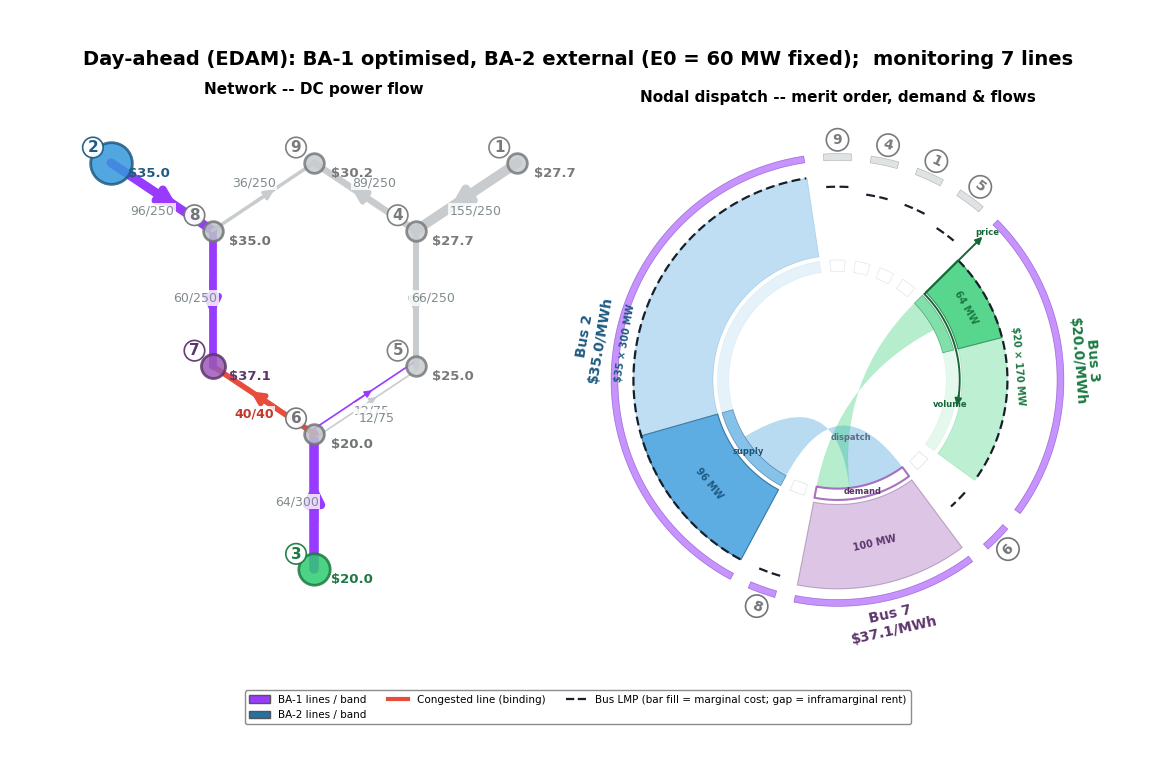

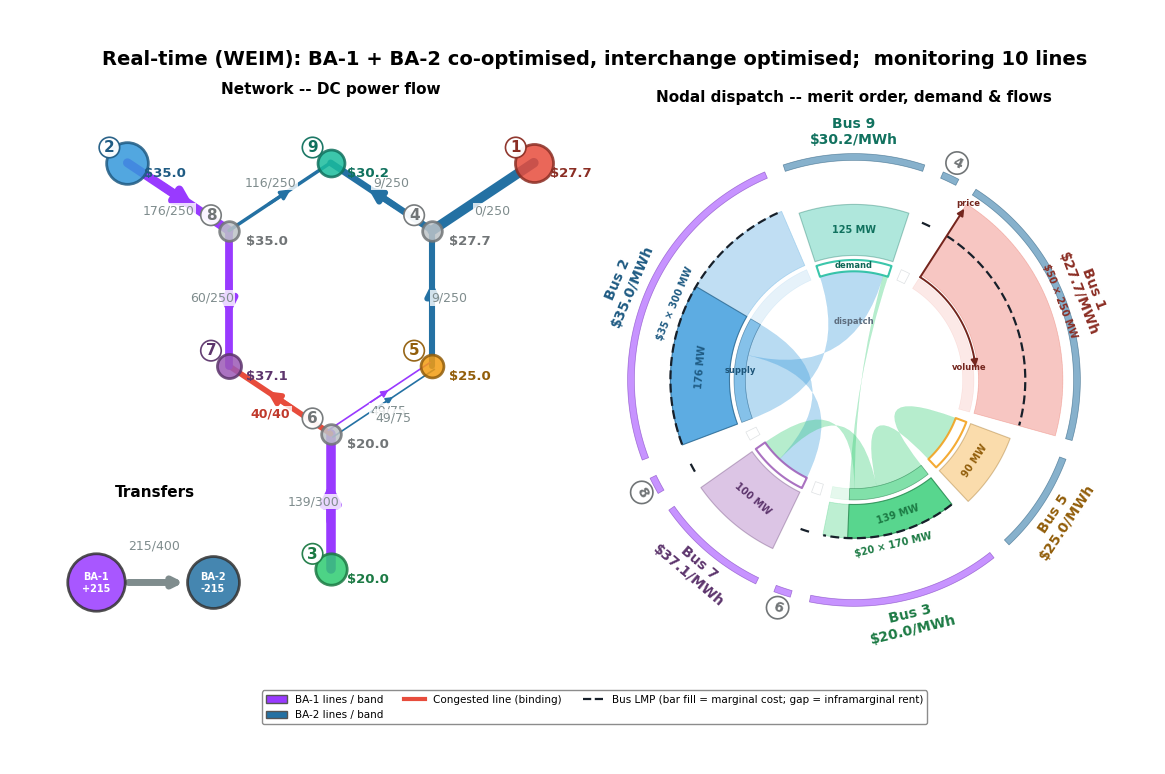

In [16]:
# Composite network + nodal dispatch for each settlement.
# Day-ahead: BA-2 is greyed -- it is outside the market (its bus-1 unit self-
# schedules; only the fixed bilateral E0 crosses the border).
fig = example_figure(nDA, pDA, eDA, rDA, dim_buses=BA_DEFS['BA-2'],
                     suptitle=f'Day-ahead (EDAM): BA-1 optimised, BA-2 external '
                              f'(E0 = {E0_DA:.0f} MW fixed);  monitoring '
                              f'{len(MACT_DA)} lines')
plt.show()
# Real-time: both footprints co-optimised, transfer optimised (Transfers inset).
fig = transfer_figure(nRT, pRT, eRT, rRT, EBAR_RT,
                      suptitle=f'Real-time (WEIM): BA-1 + BA-2 co-optimised, '
                               f'interchange optimised;  monitoring {len(MACT_RT)} lines')
plt.show()


In [17]:
# In-market settlement, per settlement footprint, at that settlement's LMPs.
print('Day-ahead in-market settlement -- BA-1 only, at day-ahead LMPs:')
display(settlement_by_bus(rDA, BA_DEFS['BA-1'], LOADS))
print('Day-ahead congestion rent, on the monitored day-ahead set M_act^DA:')
display(capacity_value_by_line(rDA, pDA, MACT_DA))
print(f"BA-2 is outside the day-ahead market: it self-supplies {sum(LOADS[b] for b in BA_DEFS['BA-2'] if b in LOADS) - E0_DA:.0f} MW "
      f"at its own $50 unit and imports the fixed E0 = {E0_DA:.0f} MW. Its settlement sits outside this market.\n")

print('Real-time in-market settlement -- BA-1 + BA-2, at real-time LMPs:')
display(settlement_by_bus(rRT, pt.buses, LOADS))
print('Real-time congestion rent, on the monitored real-time set M_act^RT:')
display(capacity_value_by_line(rRT, pRT, MACT_RT))
RT_RT = transfer_rent(rRT)
print(f"real-time transfer rent R_T = |mu_T * E| = ${RT_RT:,.1f}/h"
      + ('' if RT_RT > 1e-3 else '  (transfer not binding at this Ebar)'))


Day-ahead in-market settlement -- BA-1 only, at day-ahead LMPs:

,LMP ($/MWh),gen (MW),paid to gen ($/h),load (MW),paid by load ($/h)
bus,,,,,
2,35.0,96.1,3364.5,0.0,0.0
8,35.0,0.0,0.0,0.0,0.0
7,37.13,0.0,0.0,100.0,3712.6
6,20.0,0.0,0.0,0.0,0.0
3,20.0,63.9,1277.4,0.0,0.0
SUBTOTAL,,160.0,4641.9,100.0,3712.6


Day-ahead congestion rent, on the monitored day-ahead set M_act^DA:

,from,to,flow (MW),rating (MW),binding,|mu| ($/MWh = value of +1 MW),rent |mu| x flow ($/h)
line,,,,,,,
line_3,3,6,63.9,300.0,False,0.0,0.0
line_4,6,7,40.0,40.0,True,20.1,804.1
line_5,7,8,-60.0,250.0,False,0.0,0.0
line_6,8,2,-96.1,250.0,False,0.0,0.0
line_7,8,9,36.1,250.0,False,0.0,0.0
line_2_ba1,5,6,-11.9,75.0,False,0.0,0.0
line_2_ba2,5,6,-11.9,75.0,False,0.0,0.0
TOTAL,,,,,,,804.1


BA-2 is outside the day-ahead market: it self-supplies 155 MW at its own $50 unit and imports the fixed E0 = 60 MW. Its settlement sits outside this market.


Real-time in-market settlement -- BA-1 + BA-2, at real-time LMPs:

,LMP ($/MWh),gen (MW),paid to gen ($/h),load (MW),paid by load ($/h)
bus,,,,,
1,27.74,0.0,0.0,0.0,0.0
2,35.0,176.1,6162.4,0.0,0.0
3,20.0,138.9,2778.6,0.0,0.0
4,27.74,0.0,0.0,0.0,0.0
5,25.02,0.0,0.0,90.0,2251.8
6,20.0,0.0,0.0,0.0,0.0
7,37.13,0.0,0.0,100.0,3712.6
8,35.0,0.0,0.0,0.0,0.0
9,30.25,0.0,0.0,125.0,3780.8


Real-time congestion rent, on the monitored real-time set M_act^RT:

,from,to,flow (MW),rating (MW),binding,|mu| ($/MWh = value of +1 MW),rent |mu| x flow ($/h)
line,,,,,,,
line_0,1,4,0.0,250.0,False,0.0,0.0
line_1,4,5,-8.9,250.0,False,0.0,0.0
line_3,3,6,138.9,300.0,False,0.0,0.0
line_4,6,7,40.0,40.0,True,20.1,804.1
line_5,7,8,-60.0,250.0,False,0.0,0.0
line_6,8,2,-176.1,250.0,False,0.0,0.0
line_7,8,9,116.1,250.0,False,0.0,0.0
line_8,9,4,-8.9,250.0,False,0.0,0.0
line_2_ba1,5,6,-49.5,75.0,False,0.0,0.0


real-time transfer rent R_T = |mu_T * E| = $0.0/h  (transfer not binding at this Ebar)

### The cross-settlement position ledger

Absent day-ahead participation, BA-2 still needs a **schedule**. The proxy is a
**private self-commitment plus a bilateral**: BA-2 commits its own units (merit
order) to serve its load net of a fixed bilateral $E_0$ bought from BA-1 — the
same private commitment a non-participant runs in place of the market
optimisation. The bilateral settles at a private price $P_{\mathrm{BILAT}}$,
which **splits the day-ahead gains from trade** between the two parties; the
default is the midpoint of BA-1's day-ahead marginal cost and BA-2's avoided
cost ($\$50$), sharing them equally.

The ledger compares **three stages of integration**:

- **Autarky** — each BA self-supplies *all* its load alone (no trade): the
  before-anything reference.
- **Day-ahead (EDAM + bilateral)** — BA-1 clears its day-ahead market; BA-2
  self-commits and imports the fixed $E_0$ at $P_{\mathrm{BILAT}}$.
- **Real-time (WEIM)** — both co-optimised, interchange optimised.

Net positions are cash-out-negative and **sum to $-$(system production cost)**
at each stage, so each column's SYSTEM total is the efficiency of that stage and
the $\Delta$-vs-autarky columns are the gains each BA captures. The bilateral
price is a pure transfer — it moves the day-ahead gains between BA-1 and BA-2 but
cancels in the SYSTEM total. Settling who keeps the **real-time** savings is the
same Method-1/Method-2 allocation question as the single-settlement case.


In [18]:
# -- EDIT -- the private bilateral price (the day-ahead gains-from-trade split)
P_BILAT = 0.5 * (rDA.energy_price + BA2_SELF)   # midpoint of BA-1's DA marginal and BA-2's $50 -> equal shares
# ---------------------------------------------------------------------------

# BA-2's private self-commitment schedule (its dispatch absent the market).
load2 = sum(LOADS[b] for b in BA_DEFS['BA-2'] if b in LOADS)
priv, need = [], load2 - E0_DA
for g, s in sorted(((g, s) for g, s in GEN_FLEET.items() if ba_of(s['bus']) == 'BA-2'),
                   key=lambda kv: kv[1]['cost']):
    take = max(0.0, min(need, s['p_nom'])); need -= take
    priv.append({'unit': g, 'bus': s['bus'], 'cost $/MWh': s['cost'], 'self-committed MW': round(take, 0)})
print(f"BA-2 private self-commitment (absent day-ahead participation): serves its {load2:.0f} MW "
      f"load minus the E0 = {E0_DA:.0f} MW bilateral from BA-1, at P_BILAT = ${P_BILAT:.1f}/MWh.")
display(pd.DataFrame(priv).set_index('unit'))

# Net positions ($/h) at each stage.
_, indep = independent_clear(SCN, shed_price=SHED_PRICE)
def _pc(res, ba): return sum(COST.get(b, 0.0) * res.gen_by_bus.get(b, 0.0) for b in BA_DEFS[ba])
PC1_DA  = _pc(rDA, 'BA-1')
PC2self = sum(COST.get(b, 0.0) * max(0.0, exoDA.get(b, 0.0)) for b in BA_DEFS['BA-2'])
allocDA, summDA, _, _ = allocate_congestion_rent(rDA, pDA, LOADS_ALL)
allocRT, summRT, _, _ = allocate_congestion_rent(rRT, pRT, LOADS_ALL)
RT_xfer = transfer_rent(rRT)

def net_rt(ba):                          # real-time: homework settlement (eq. style of Sec 1)
    L, R, PC = _agg(rRT, ba)
    return -L + float(allocRT.loc[ba, 'method1']) + (R - PC)   # + transfer rent (0 unless the border binds)

net = {
    'Autarky (self-supply)':        {ba: -_pc(indep[ba], ba) for ba in BA_DEFS},
    'Day-ahead (EDAM + bilateral)': {'BA-1': P_BILAT * E0_DA - PC1_DA,
                                     'BA-2': -PC2self - P_BILAT * E0_DA},
    'Real-time (WEIM)':             {ba: net_rt(ba) for ba in BA_DEFS},
}
led = pd.DataFrame(net).T[['BA-1', 'BA-2']]
led['SYSTEM'] = led.sum(axis=1)
print('\nNet position by balancing authority ($/h; cash out negative; SYSTEM = -(production cost)):')
display(led.round(0))

base = led.loc['Autarky (self-supply)']
delta = pd.DataFrame({ba + ' (vs autarky)': (led[ba] - base[ba]).round(0) for ba in BA_DEFS})
delta['Pareto (both >= 0)'] = ['--' if i == 0 else
    ('yes' if all((led[ba] - base[ba]).iloc[i] >= -1.0 for ba in BA_DEFS) else 'no')
    for i in range(len(delta))]
print('Gains captured vs autarky ($/h; >= 0 = that BA is better off than going it alone):')
display(delta)

pc_aut = sum(_pc(indep[ba], ba) for ba in BA_DEFS)
da_gain = pc_aut - (PC1_DA + PC2self)
b1_da = led.loc['Day-ahead (EDAM + bilateral)', 'BA-1'] - base['BA-1']
b2_da = led.loc['Day-ahead (EDAM + bilateral)', 'BA-2'] - base['BA-2']
print(f"\nsystem production cost:  autarky ${pc_aut:,.0f}  ->  day-ahead ${PC1_DA + PC2self:,.0f}  ->  "
      f"real-time ${system_production_cost(rRT):,.0f} /h")
print(f"day-ahead gains from trade (autarky - day-ahead production cost) = ${da_gain:,.0f}/h; "
      f"P_BILAT = ${P_BILAT:.1f}/MWh splits it  BA-1 +${b1_da:,.0f}  /  BA-2 +${b2_da:,.0f}.")
print(f"real-time captures the FULL value of participation: ${pc_aut - system_production_cost(rRT):,.0f}/h vs autarky, "
      f"almost all to BA-2 (the importer) -- BA-1's units earn LMP = cost.")
print(f"congestion rent: DA ${summDA['R']:,.0f} (BA-1's line_4) | RT ${summRT['R']:,.0f};  transfer rent RT ${RT_xfer:,.0f}")


BA-2 private self-commitment (absent day-ahead participation): serves its 215 MW load minus the E0 = 60 MW bilateral from BA-1, at P_BILAT = $38.9/MWh.

,bus,cost $/MWh,self-committed MW
unit,,,
gen_slack_0,1,50.0,155.0


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines



Net position by balancing authority ($/h; cash out negative; SYSTEM = -(production cost)):

,BA-1,BA-2,SYSTEM
Autarky (self-supply),-2909.0,-10750.0,-13659.0
Day-ahead (EDAM + bilateral),-2310.0,-10082.0,-12392.0
Real-time (WEIM),-2909.0,-6033.0,-8941.0


...

,BA-1 (vs autarky),BA-2 (vs autarky),Pareto (both >= 0)
Autarky (self-supply),0.0,0.0,--
Day-ahead (EDAM + bilateral),599.0,668.0,yes
Real-time (WEIM),0.0,4717.0,yes



system production cost:  autarky $13,659  ->  day-ahead $12,392  ->  real-time $8,941 /h

day-ahead gains from trade (autarky - day-ahead production cost) = $1,267/h; P_BILAT = $38.9/MWh splits it  BA-1 +$599  /  BA-2 +$668.

real-time captures the FULL value of participation: $4,717/h vs autarky, almost all to BA-2 (the importer) -- BA-1's units earn LMP = cost.

congestion rent: DA $804 (BA-1's line_4) | RT $804;  transfer rent RT $0

**Read it.** The same constraint, two footprints, three stages of integration:

- **Day-ahead.** BA-2 is outside the market, self-committing its **own $50 unit**
  plus the fixed bilateral $E_0$; the price it faces is **~\$50/MWh**. The cheap
  BA-1 fleet cannot displace that generation, and the day-ahead market never
  monitors BA-2's own lines. The bilateral captures only **part** of the gains
  from trade ($E_0\times(\$50-\lambda^{DA})$), split between the parties by
  $P_{\mathrm{BILAT}}$.
- **Real-time.** BA-2 joins. Its generation becomes a **decision variable**, the
  cheap BA-1 energy flows to its load, the interchange is optimised, the formerly
  invisible BA-2-internal lines are monitored, and the price at its buses **falls
  into the high-\$20s/\$30s**. Real-time captures the **full** value of
  participation.

The position ledger makes this concrete: each stage's SYSTEM total is its
production cost, and both BAs are better off than autarky at each step (Pareto).
Day-ahead is a **commitment** decision made privately by the non-participant;
real-time is the **dispatch** that makes its resources endogenous. Who keeps the
real-time savings remains a Method-1/Method-2 allocation choice.

The next section turns to the case that motivates all of this: a **contingency**
whose relieving resources sit outside the day-ahead footprint — managed bluntly
day-ahead, efficiently once real-time participation makes them endogenous.


## 4. A contingency outside the day-ahead footprint

The sharpest case is **reliability**. A contingency is the loss of an element;
the market must keep the post-contingency flows within limits. Whether it *can*
depends on whose resources are inside its dispatch.

The 5-6 interface is modelled as the two **parallel circuits** it really is —
one **operated by each balancing authority**, visible in every network diagram —
so the contingency is a genuine **BA-2 facility**. (The single `line_2` was split
into `line_2_ba1` + `line_2_ba2` by the standard PyPSA-Eur disaggregation, so the
pair is electrically identical to the original line.)

The institutional setup matters:

- **Day-ahead (EDAM = BA-1)** clears *and settles*, dispatching **its own** loads
  and resources to respect the contingency. It does its part — but it commands
  only its own resources.
- **BA-2** is **not under the market's dispatch instruction**. It self-dispatches
  **generically** — serving its load by its own logic (here, importing cheap
  BA-1 energy), with no obligation to respect BA-1's reliability limit. **BA-2
  does not settle day-ahead.**
- **Real-time (WEIM)** is the **unified clearing**: BA-2's dispatch becomes
  **coordinated and endogenous**, and it settles here.


### The contingency and the reliability limit

The 5-6 interface is two parallel circuits: `line_2_ba1` (operated by BA-1, the
**monitored** circuit) and `line_2_ba2` (operated by BA-2, the **contingency**).
Each is rated 75 MW — the original 150 MW line split in two by the standard rule
(each circuit carries half the rating at twice the reactance, so the pair is
electrically identical to the single line). They share the corridor evenly, so
losing one throws most of it onto the survivor:

$$F^{\text{post}}_{\text{ba1}} = F_{\text{ba1}} + \text{LODF}\cdot F_{\text{ba2}}
  = (1+\text{LODF})\,F_{\text{ba1}}, \qquad (8)$$

with the line-outage distribution factor $\text{LODF}\approx0.6$ — the remaining
~40% reroutes onto the other tie, `line_7`. The reliability rule holds BA-1's
circuit low enough in the base case that post-contingency it lands at its 75 MW
rating:

$$F_{\text{ba1}} \le \frac{\bar F_{\text{ba1}}}{1+\text{LODF}} \approx 47\ \text{MW}. \qquad (9)$$


In [19]:
# The 5-6 interface is the parallel double-circuit from Section 1: line_2_ba1
# (operated by BA-1, the monitored circuit) and line_2_ba2 (operated by BA-2,
# the contingency). Each carries half the corridor.
CIRCUIT_MW = float(build_network().lines.loc['line_2_ba1', 's_nom'])   # 75 MW per circuit

# post-contingency flows after BA-2's circuit trips (same injection, no redispatch)
_nctg = build_network(); _nctg.remove('Line', 'line_2_ba2')
pt_ctg = compute_ptdf(_nctg, slack_bus='1')
def post_ctg(res, line='line_2_ba1'):
    return float((pt_ctg.ptdf @ res.injection)[pt_ctg.line_idx[line]])

# Economic real-time clearing (N-1 not yet imposed) and the contingency:
nC, pC, eC, rC = rt_clear({})
LODF = post_ctg(rC) / rC.flow_own['line_2_ba1'] - 1.0   # share of the lost circuit the survivor picks up
DERATE_N1 = CIRCUIT_MW / (1.0 + LODF)                   # base limit so post-contingency lands at the rating
ctg_tbl = pd.DataFrame({
    'rating (MW)':           {'line_2_ba1': CIRCUIT_MW, 'line_2_ba2': CIRCUIT_MW},
    'base flow (MW)':        {'line_2_ba1': round(rC.flow_own['line_2_ba1'], 0),
                              'line_2_ba2': round(rC.flow_own['line_2_ba2'], 0)},
    'post-contingency (MW)': {'line_2_ba1': round(post_ctg(rC), 0), 'line_2_ba2': 0.0},
    'overload?':             {'line_2_ba1': abs(post_ctg(rC)) > CIRCUIT_MW, 'line_2_ba2': False},
})
print('The 5-6 interface is two parallel circuits sharing the corridor evenly.')
print("Lose BA-2's circuit (line_2_ba2) -> BA-1's circuit carries most of the corridor:")
display(ctg_tbl)
print(f'Outage distribution factor (line_2_ba2 -> line_2_ba1) = {LODF:.2f} '
      f'(the rest reroutes onto the other tie, line_7).')
print(f'N-1 rule: BA-1 holds line_2_ba1 <= {DERATE_N1:.1f} MW (so post-contingency it lands at {CIRCUIT_MW:.0f}).')


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


The 5-6 interface is two parallel circuits sharing the corridor evenly.

Lose BA-2's circuit (line_2_ba2) -> BA-1's circuit carries most of the corridor:

,rating (MW),base flow (MW),post-contingency (MW),overload?
line_2_ba1,75.0,-53.0,-85.0,True
line_2_ba2,75.0,-53.0,0.0,False


Outage distribution factor (line_2_ba2 -> line_2_ba1) = 0.60 (the rest reroutes onto the other tie, line_7).

N-1 rule: BA-1 holds line_2_ba1 <= 46.9 MW (so post-contingency it lands at 75).

### Day-ahead — BA-1 keeps it secure, but only with its own resources

BA-2 is not under the market's instruction, so it **self-schedules generically**:
it imports cheap BA-1 energy to cover its entire load (a privately rational
schedule that ignores the N-1 limit). BA-1 takes that schedule as fixed and can
move only **its own** resources. Two things follow:

1. **If BA-1 simply honours the schedule**, the uncoordinated import loads the
   corridor and the **post-contingency flow overloads** BA-1's circuit — the
   reliability violation.
2. **To respect the N-1 limit**, BA-1 reroutes flow through the other tie by
   redispatching its own units. It *can* keep the system secure — but only with a
   **more expensive dispatch**, because the resource that would relieve the
   corridor most cheaply (BA-2's own generation) is **outside its reach**.

BA-2 does not settle day-ahead.


In [20]:
GENERIC_IMPORT = 215.0   # BA-2's generic day-ahead self-schedule: import its whole load as cheap BA-1 energy
print(f"BA-2 self-schedules generically: import {GENERIC_IMPORT:.0f} MW of its "
      f"{sum(LOADS[b] for b in BA_DEFS['BA-2'] if b in LOADS):.0f} MW load from BA-1.\n")

# (1) BA-1 honours the schedule -> post-contingency overload
nH, pH, eH, rH = da_clear({}, E0=GENERIC_IMPORT)
print(f"(1) BA-1 serves the schedule (circuit at thermal {CIRCUIT_MW:.0f}, N-1 not yet imposed):")
print(f"    base line_2_ba1 = {rH.flow_own['line_2_ba1']:.0f}/{CIRCUIT_MW:.0f}  ->  POST-CONTINGENCY "
      f"{post_ctg(rH):.0f}/{CIRCUIT_MW:.0f}  --  {'N-1 VIOLATION' if abs(post_ctg(rH)) > CIRCUIT_MW else 'ok'}")

# (2) BA-1 enforces the N-1 de-rate with only its own resources -> secure, but pricier
nS, pS, eS, rS = da_clear({'line_2_ba1': DERATE_N1}, E0=GENERIC_IMPORT)
DA_COST = system_production_cost(rS, E0=GENERIC_IMPORT)
print(f"\n(2) BA-1 enforces the N-1 limit (line_2_ba1 <= {DERATE_N1:.1f}) with only its own resources:")
print(f"    base line_2_ba1 = {rS.flow_own['line_2_ba1']:.1f}/{DERATE_N1:.1f}  post-contingency {post_ctg(rS):.0f}/{CIRCUIT_MW:.0f} (secure);")
print(f"    it reroutes through the other tie at a system production cost of ${DA_COST:,.0f}/h.")
print("    It cannot redispatch BA-2's units, so this is the cheapest secure dispatch it can reach alone.")
print("    BA-2 does not settle day-ahead.")


BA-2 self-schedules generically: import 215 MW of its 215 MW load from BA-1.


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


(1) BA-1 serves the schedule (circuit at thermal 75, N-1 not yet imposed):

    base line_2_ba1 = -53/75  ->  POST-CONTINGENCY -85/75  --  N-1 VIOLATION

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines



(2) BA-1 enforces the N-1 limit (line_2_ba1 <= 46.9) with only its own resources:

    base line_2_ba1 = -46.9/46.9  post-contingency -75/75 (secure);

    it reroutes through the other tie at a system production cost of $9,249/h.

    It cannot redispatch BA-2's units, so this is the cheapest secure dispatch it can reach alone.

    BA-2 does not settle day-ahead.

### Real-time — coordination makes it cheaper

In the unified clearing BA-2's dispatch is **endogenous**. The market does the
one thing the day-ahead could not: it **ramps BA-2's own generation** so BA-2
serves more of its load locally and imports less, the corridor falls below the
N-1 limit, and the **same reliability standard is met at a lower production
cost**. The binding circuit prices out — congestion rent on `line_2_ba1` — and
the border separates (BA-1 buses cheap, BA-2 buses up at their own marginal
cost). BA-2 settles here.

*What changed is the dispatch, not the wires:* BA-2's generation crossed from a
generic, uncoordinated self-schedule to a co-optimised market decision, and the
**cost gap between the two secure solutions is the value of that coordination.**


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


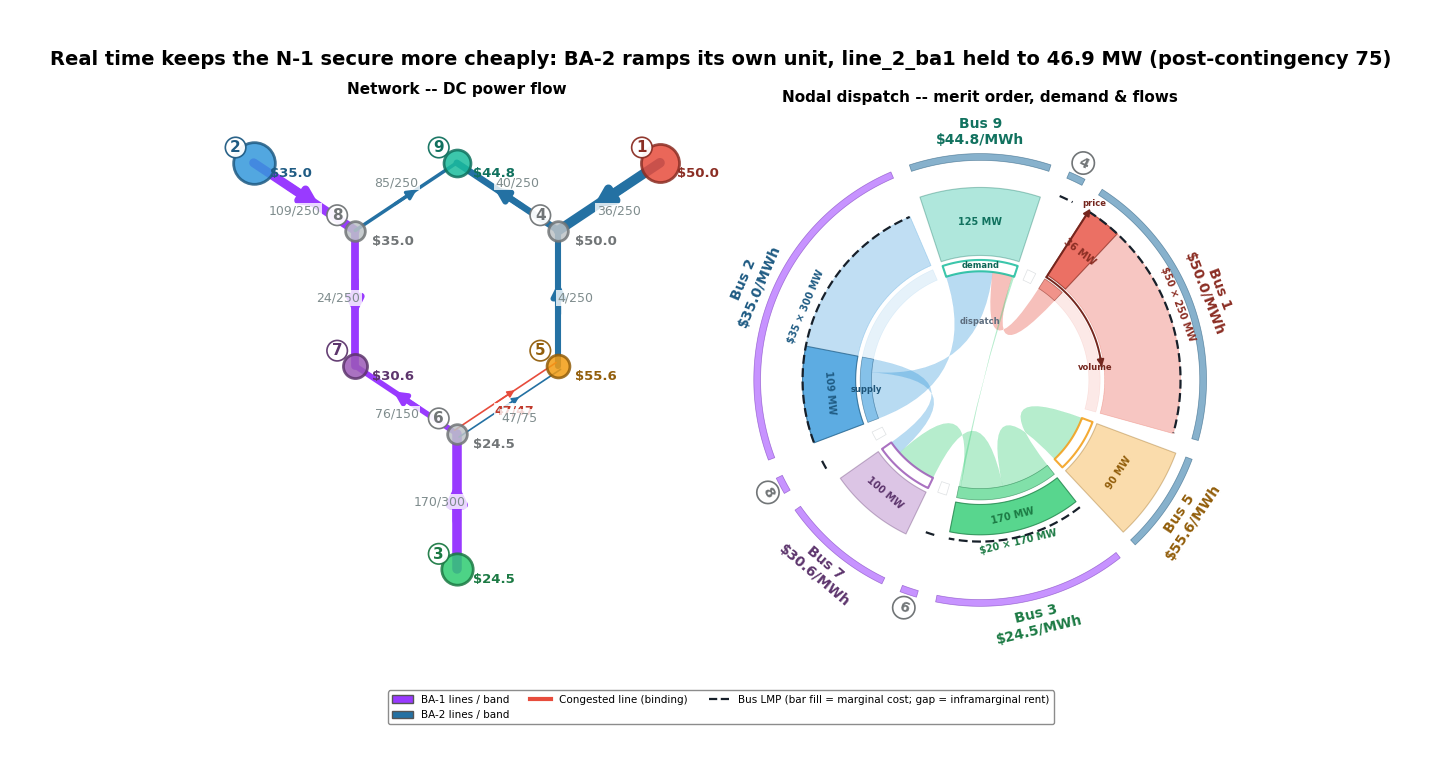

BA-2's own unit ramps to 36 MW (serves locally instead of importing);  BA-1 net export falls to 179 MW (from the 215 MW generic import).

the N-1 limit is held at a production cost of $9,018/h -- $230/h cheaper than the day-ahead's BA-1-only solution ($9,249/h). That gap is the value of coordinating BA-2.

base line_2_ba1 = -46.9/46.9  ->  post-contingency -75/75 (secure).

border LMPs:

{'1': np.float64(50.0), '2': np.float64(35.0), '3': np.float64(24.0), '4': np.float64(50.0), '5': np.float64(56.0), '6': np.float64(24.0), '7': np.float64(31.0), '8': np.float64(35.0), '9': np.float64(45.0)}

BA-1 buses clear in the $20s-30s, BA-2 buses at ~$50; congestion rent on line_2_ba1 = $3,891/h.

In [21]:
nR, pR, eR, rR = rt_clear({'line_2_ba1': DERATE_N1})
fig = example_figure(nR, pR, eR, rR,
                     suptitle=f'Real time keeps the N-1 secure more cheaply: BA-2 ramps its own unit, '
                              f'line_2_ba1 held to {DERATE_N1:.1f} MW (post-contingency {CIRCUIT_MW:.0f})')
plt.show()

RT_COST = system_production_cost(rR)
cong = abs(rR.line_dual['line_2_ba1'] * rR.flow_own['line_2_ba1'])
E_rt = (sum(rR.gen_by_bus.get(b, 0.0) for b in BA_DEFS['BA-1'])
        - sum(LOADS_ALL.get(b, 0.0) - rR.shed_by_bus.get(b, 0.0) for b in BA_DEFS['BA-1']))
print(f"BA-2's own unit ramps to {rR.gen_by_bus.get('1', 0):.0f} MW (serves locally instead of importing);  "
      f"BA-1 net export falls to {E_rt:.0f} MW (from the {GENERIC_IMPORT:.0f} MW generic import).")
print(f"the N-1 limit is held at a production cost of ${RT_COST:,.0f}/h -- ${DA_COST - RT_COST:,.0f}/h cheaper "
      f"than the day-ahead's BA-1-only solution (${DA_COST:,.0f}/h). That gap is the value of coordinating BA-2.")
print(f"base line_2_ba1 = {rR.flow_own['line_2_ba1']:.1f}/{DERATE_N1:.1f}  ->  post-contingency {post_ctg(rR):.0f}/{CIRCUIT_MW:.0f} (secure).")
print('border LMPs:', {b: round(rR.lmp[b], 0) for b in pR.buses})
print(f"BA-1 buses clear in the $20s-30s, BA-2 buses at ~$50; congestion rent on line_2_ba1 = ${cong:,.0f}/h.")


### Exogenous in the day-ahead, endogenous in real time

The whole section turns on **whose dispatch the clearing controls**. The
contingency element is BA-2's; so is the resource that relieves it. Both are
outside the day-ahead market and inside the real-time one:


In [22]:
acct = pd.DataFrame({
    'Day-ahead (EDAM: BA-1)': {
        "BA-2's generation":                 'exogenous -- generic self-schedule, uncoordinated',
        'the contingency (BA-2 circuit)':    "outside BA-1's dispatch",
        'who can relieve the corridor':      'only BA-1 (cannot move BA-2)',
        'outcome under the N-1 limit':       'secure, but a more expensive BA-1-only dispatch',
        'BA-2 settlement':                   'none (settles only in real-time)',
    },
    'Real-time (WEIM: BA-1 + BA-2)': {
        "BA-2's generation":                 'endogenous -- co-optimised, coordinated',
        'the contingency (BA-2 circuit)':    'inside the unified dispatch',
        'who can relieve the corridor':      "BA-2's own units (ramp to serve locally)",
        'outcome under the N-1 limit':       'secure at lower cost; circuit prices out',
        'BA-2 settlement':                   'settles in the unified clearing',
    },
}).reindex(["BA-2's generation", 'the contingency (BA-2 circuit)', 'who can relieve the corridor',
            'outcome under the N-1 limit', 'BA-2 settlement'])
display(acct)
print('The contingency sits on a BA-2 facility and is relieved most cheaply by BA-2 resources. The')
print('day-ahead market can neither dispatch nor settle them, so it keeps the system secure only by a')
print('costlier BA-1-only redispatch. Real-time participation turns that generic, exogenous dispatch')
print('into a coordinated, endogenous, priced one -- and the production-cost gap between the two secure')
print('solutions is what participation is worth. Participation is what makes the contingency cheap to')
print('manage -- and reliability priceable.')


,Day-ahead (EDAM: BA-1),Real-time (WEIM: BA-1 + BA-2)
BA-2's generation,"exogenous -- generic self-schedule, uncoordinated","endogenous -- co-optimised, coordinated"
the contingency (BA-2 circuit),outside BA-1's dispatch,inside the unified dispatch
who can relieve the corridor,only BA-1 (cannot move BA-2),BA-2's own units (ramp to serve locally)
outcome under the N-1 limit,"secure, but a more expensive BA-1-only dispatch",secure at lower cost; circuit prices out
BA-2 settlement,none (settles only in real-time),settles in the unified clearing


The contingency sits on a BA-2 facility and is relieved most cheaply by BA-2 resources. The

day-ahead market can neither dispatch nor settle them, so it keeps the system secure only by a

costlier BA-1-only redispatch. Real-time participation turns that generic, exogenous dispatch

into a coordinated, endogenous, priced one -- and the production-cost gap between the two secure

solutions is what participation is worth. Participation is what makes the contingency cheap to

manage -- and reliability priceable.

## 5. Inefficient accommodation of the contingency

Section 4 let BA-1 hold its circuit to the *exact* N-1 de-rate. In practice it
cannot: day-ahead it does not know how the flow will actually divide — only a
forecast — and it cannot coordinate BA-2. So it does what an **Available Transfer
Capability (ATC)** process does — it **reserves room** on the monitored circuit
for the flow the contingency would redistribute onto it, sized from a forecast
and padded with a conservatism margin. (This mirrors the inefficient-accommodation
seam issue, here applied to a contingency rather than a neighbour's loop flow.)

The reservation restores N-1 security. Its cost is that the reserved room is
**exogenous** — fixed before the clear, from a forecast of the flow times a
margin. Reserve too little and the post-contingency wire still overloads; reserve
too much and capability the coordinated clearing would use sits idle — or the
schedule cannot be served at all.


### The reservation and the effective limit

BA-1 enforces its monitored circuit at the **rating minus the room it reserves**
for the contingency's redistribution:

$$\lvert F^{DA}_m\rvert + \widehat G_m \le \bar F_m,\qquad m=\texttt{line\_2\_ba1}. \qquad (10)$$

*In words.* The base flow BA-1 schedules on the circuit, plus the headroom it
holds for the flow the outage would push onto it, stays within the rating. The
reserved headroom enters the clear as a **constant** (`flow_offsets`), not a
decision variable.

**The reservation is the forecast post-contingency increment times a margin.**

$$\widehat G_m = \beta\,\text{LODF}_m\,F^{\mathrm{ref}}_m,\qquad \beta\ge 1. \qquad (11)$$

*In words.* $\text{LODF}_m\,F^{\mathrm{ref}}_m$ is the flow the survivor picks up
when its twin trips, evaluated at a **reference** flow $F^{\mathrm{ref}}_m$ — here
the circuit's loading in the unconstrained economic clearing (the best
forecast BA-1 has, before reliability is imposed). The margin $\beta$ is the
ATC-style conservatism — held distinct from any risk-aversion coefficient — and
its cost is capability withheld from the market.


In [23]:
# -- EDIT -- the reservation BA-1 makes for the contingency -----------------
ATC_MARGIN = 1.0    # beta: 1.0 reserves exactly the forecast post-contingency increment
# ---------------------------------------------------------------------------
Fref = abs(rC.flow_own['line_2_ba1'])          # forecast flow = the circuit's loading in the economic clearing (4.1)

def da_accommodated(beta):
    """BA-1's day-ahead clear at the circuit's THERMAL rating, but holding back
    beta*LODF*Fref of headroom for the contingency (the reservation, as a fixed
    flow_offset). beta=0 reserves nothing (blind)."""
    off = {'line_2_ba1': -beta * LODF * Fref}   # reserve headroom in the direction of the (negative) flow
    return solve_engine_dispatch(
        compute_ptdf(build_network(), slack_bus='1'),
        make_engine('BA-1 (EDAM)', BA_DEFS['BA-1'], activated=MACT_DA),
        exo=da_exo(GENERIC_IMPORT), flow_offsets=off, shed_price=SHED_PRICE)

rAcc = da_accommodated(ATC_MARGIN)
ACC_COST = system_production_cost(rAcc, E0=GENERIC_IMPORT)
print(f'BA-1 reserves {ATC_MARGIN * LODF * Fref:.0f} MW of headroom on line_2_ba1 '
      f'(LODF {LODF:.2f} x forecast flow {Fref:.0f} x margin {ATC_MARGIN:.2f}).\n')

cmp = pd.DataFrame([
    {'arrangement': 'blind (no reservation)',
     'post-contingency line_2_ba1': f'{abs(post_ctg(da_accommodated(0.0))):.0f}/{CIRCUIT_MW:.0f} -- OVERLOAD',
     'production cost ($/h)': round(system_production_cost(da_accommodated(0.0), E0=GENERIC_IMPORT))},
    {'arrangement': f'accommodated (beta={ATC_MARGIN:.2f})',
     'post-contingency line_2_ba1': f'{abs(post_ctg(rAcc)):.0f}/{CIRCUIT_MW:.0f} -- secure',
     'production cost ($/h)': round(ACC_COST)},
    {'arrangement': 'coordinated real-time',
     'post-contingency line_2_ba1': f'{CIRCUIT_MW:.0f}/{CIRCUIT_MW:.0f} -- secure',
     'production cost ($/h)': round(RT_COST)},
]).set_index('arrangement')
display(cmp)
print(f'The blind forecast over-reserves (it uses the economic {Fref:.0f} MW, not the {DERATE_N1:.0f} MW the')
print(f'circuit actually carries once secure), so accommodation costs ${ACC_COST:,.0f}/h -- above even the')
print(f'informed de-rate of Section 4 (${DA_COST:,.0f}/h) and ${ACC_COST - RT_COST:,.0f}/h above coordination.')


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


BA-1 reserves 32 MW of headroom on line_2_ba1 (LODF 0.60 x forecast flow 53 x margin 1.00).


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


,post-contingency line_2_ba1,production cost ($/h)
arrangement,,
blind (no reservation),85/75 -- OVERLOAD,8475
accommodated (beta=1.00),69/75 -- secure,9713
coordinated real-time,75/75 -- secure,9018


The blind forecast over-reserves (it uses the economic 53 MW, not the 47 MW the

circuit actually carries once secure), so accommodation costs $9,713/h -- above even the

informed de-rate of Section 4 ($9,249/h) and $695/h above coordination.

In [24]:
# The price of conservatism: sweep the margin and watch security and cost move.
rows = []
for beta in [0.0, 0.75, 1.0, 1.25, 1.5]:
    try:
        r = da_accommodated(beta)
        post = abs(post_ctg(r)); shed = sum(r.shed_by_bus.values())
        rows.append({'margin beta': beta, 'reserved (MW)': round(beta * LODF * Fref),
                     'line_2_ba1 base (MW)': round(abs(r.flow_own['line_2_ba1'])),
                     'post-contingency (MW)': round(post),
                     'secure?': 'yes' if post <= CIRCUIT_MW + 0.1 else 'NO -- overload',
                     'shed (MW)': round(shed),
                     'cost ($/h)': round(system_production_cost(r, E0=GENERIC_IMPORT))})
    except RuntimeError:
        rows.append({'margin beta': beta, 'reserved (MW)': round(beta * LODF * Fref),
                     'line_2_ba1 base (MW)': '--', 'post-contingency (MW)': '--',
                     'secure?': 'INFEASIBLE -- cannot serve the schedule', 'shed (MW)': '--',
                     'cost ($/h)': None})
display(pd.DataFrame(rows).set_index('margin beta'))


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


,reserved (MW),line_2_ba1 base (MW),post-contingency (MW),secure?,shed (MW),cost ($/h)
margin beta,,,,,,
0.00,0,53,85,NO -- overload,0,8475.0
0.75,24,51,82,NO -- overload,0,8765.0
1.00,32,43,69,yes,0,9713.0
1.25,40,--,--,INFEASIBLE -- cannot serve the schedule,--,NaN
1.50,48,--,--,INFEASIBLE -- cannot serve the schedule,--,NaN


**Read it.** The reservation works — the post-contingency wire is safe — but at a
cost **above even Section 4's informed de-rate**, because the room is sized from a
forecast (the economic flow) and padded with a margin: BA-1 holds the circuit well
below the level the coordinated clearing actually needs. The ladder is the
Goldilocks problem made numeric: below $\beta\!\approx\!1$ the post-contingency
wire still **overloads**; well above it the reservation eats so much headroom that
BA-1 **cannot serve the schedule at all**. And the reservation is only as good as
its reference flow — one snapshot of an uncoordinated dispatch; change the loads
or the schedule and it is stale. Coordination needs no reservation: the real-time
clearing sees the actual flows and prices the circuit exactly.


## 6. Where this goes next

Two settlements, a moving boundary, and one lesson carried through prices, rents,
positions, and finally reliability: **what a market can optimise and price is
exactly what sits inside its footprint.** The day-ahead market commits a smaller
set; real-time participation turns privately-committed schedules and
out-of-footprint contingencies into endogenous, priced decisions.

Natural extensions on this same two-BA testbed:

- **A richer reliability model** — explicit line-outage distribution factors for
  every monitored (element, contingency) pair, rather than the single-survivor
  proxy used here.
- **The cross-settlement allocation** — refining how the day-ahead bilateral and
  the real-time savings are shared (the Method-1/Method-2 question, across two
  settlements and the transfer rent stream).
- **More participants** — a third balancing authority joining at a different
  settlement, so the footprint moves more than once.
